# 01 — Data Exploration (Phase 3 EDA)

Exploratory analysis of `data/processed/unified_panel.parquet` (19,356 player-seasons ×
101 columns, 9 leagues × 4 seasons). Goal: understand the data, justify the modeling
choices (log target, year inflation, position stratification, league premium), map
missingness, and surface data-quality issues before feature engineering (Phase 4) and
modeling (Phase 5/6).

> **All logic lives in `src/eda/`** (style / summary / plots). This notebook only
> orchestrates and narrates. Figures are saved to `reports/figures/` programmatically.
> Each section ends with a **Closing note** (what we saw → why it matters → Phase 4/5 action).

> ⚠️ **Data note (P2-D6):** soccerdata never delivered the FBref *extended* stats
> (total tackles, blocks, passing, touches, carries, SCA/GCA, PSxG, aerials). Those 106
> all-null columns were dropped in Phase 2. The surviving defensive/creative signal is
> `tackles_won`, `interceptions`, and xG/xAG (top-5). §6.2 Stage-1 targets were revised
> accordingly.

In [1]:
# bootstrap: make `src` importable regardless of the kernel's working directory
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "CLAUDE.md").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt

from src.utils.io import project_root, load_parquet
from src.eda import plots, summary as S
from src.eda.style import set_eda_style

set_eda_style()

In [2]:
panel = load_parquet(project_root() / "data" / "processed" / "unified_panel.parquet")
print(f"shape: {panel.shape[0]:,} rows × {panel.shape[1]} cols")
print(f"players: {panel['player_id'].nunique():,} | leagues: {panel['league'].nunique()} | seasons: {panel['season'].nunique()}")

shape: 19,356 rows × 101 cols
players: 9,072 | leagues: 9 | seasons: 4


## 1 — Setup & overview

First, the shape of the panel: how many player-seasons per league × season, and the
column inventory grouped by role (identity / context / position / performance / target /
contract / external / provenance). This view confirms the modeling substrate is balanced.

In [3]:
cats = S.categorize_columns(panel)
pd.Series({k: len(v) for k, v in cats.items()}, name="n_columns").to_frame()

,n_columns
identity,5
season_context,12
position,2
target,3
contract,3
external,3
xg,6
provenance,6
performance_clean,58
performance_namespaced,3


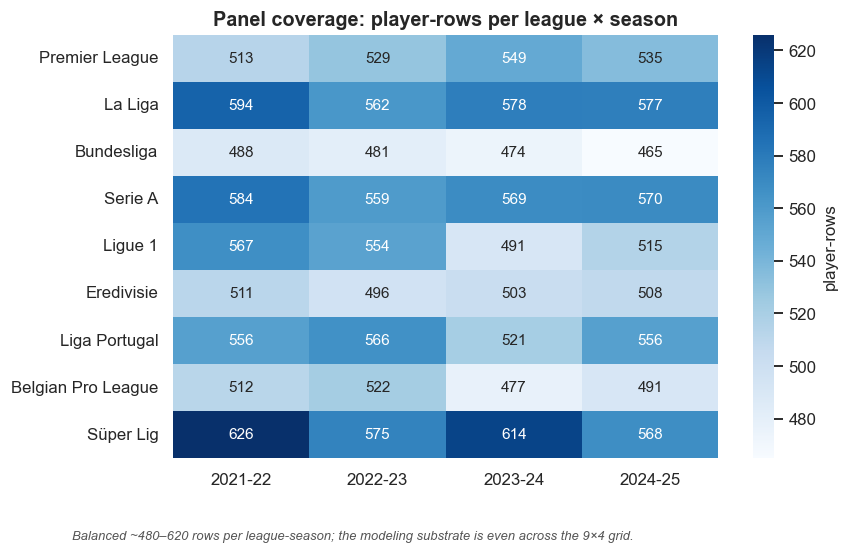

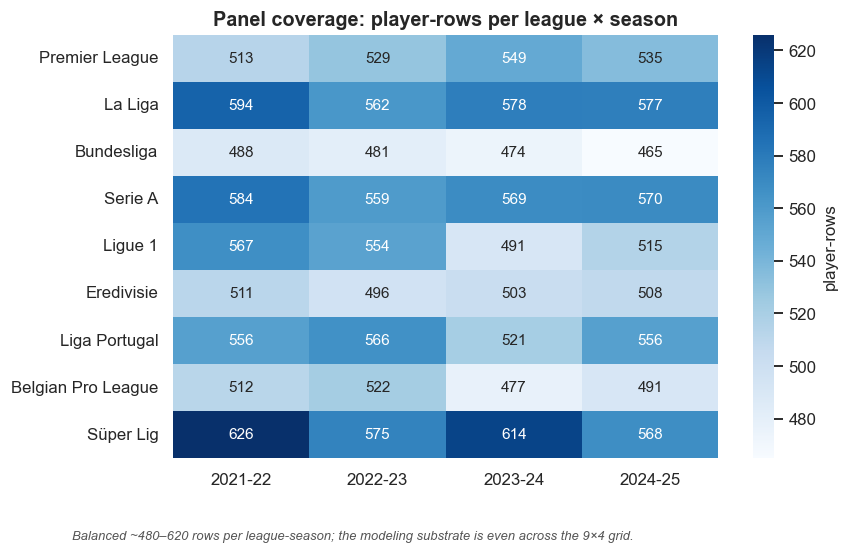

In [4]:
plots.fig01_rows_by_league_season(panel)

**Closing note.** The panel holds ~480–620 player-rows per league-season, evenly spread
across the 9×4 grid (19,356 rows, 9,072 players). Coverage is balanced, so no league or
season is structurally under-represented. **Phase 4/5:** safe to train a single global
model with league features (D-04) rather than per-league models — statistical power is even.

## 2 — Target distribution (market value)

Market value is the Stage-2 target. We check its shape (raw vs `log1p`), its YoY trend
(inflation), the league premium, and the per-position spread — each maps to a locked
decision (D-05 / D-07 / D-04 / D-03).

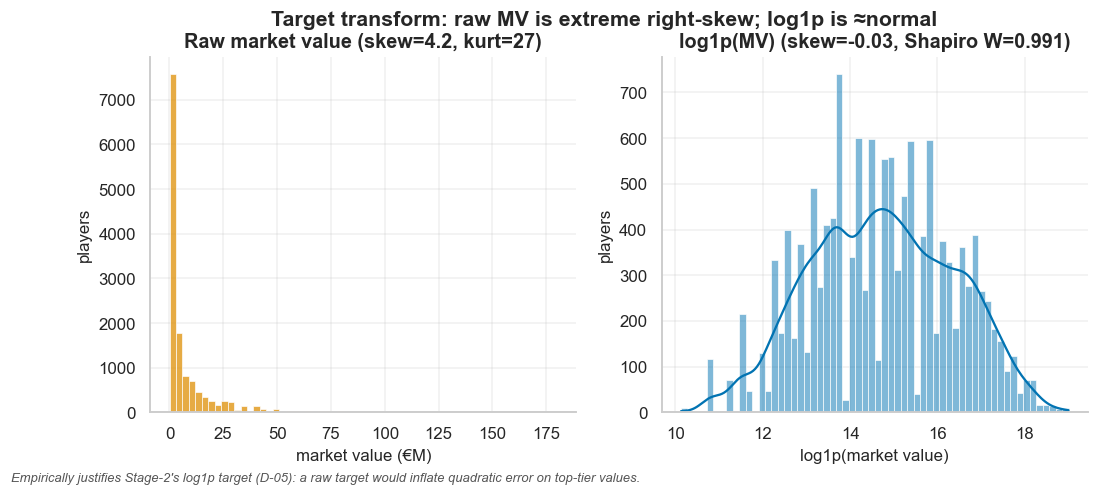

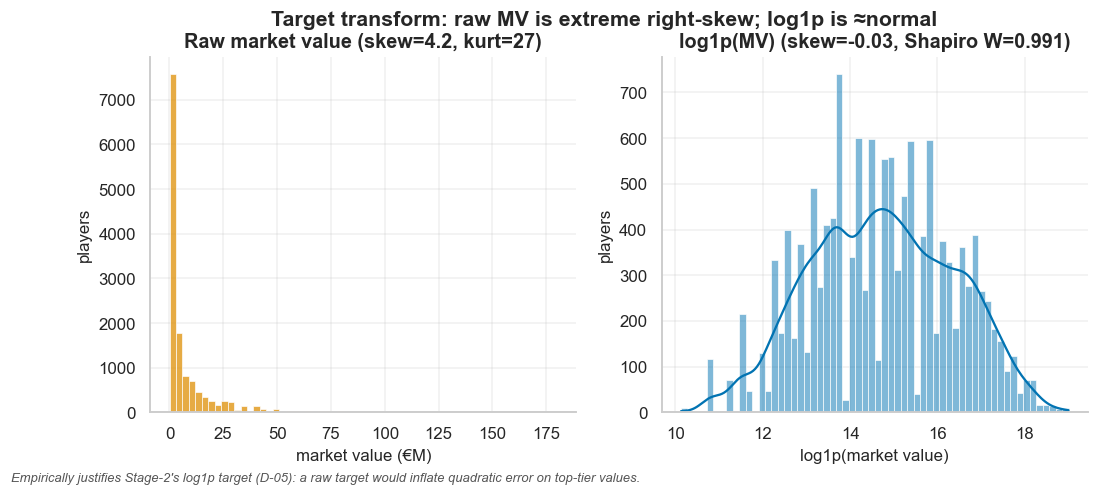

In [5]:
plots.fig02_mv_raw_vs_log_hist(panel)

In [6]:
m = S.mv_medians(panel)
display((m["by_season"] / 1e6).round(2).rename("median €M by season").to_frame())
display(pd.DataFrame({"median €M": (m["by_position_median"]/1e6).round(2),
                      "mean €M": (m["by_position_mean"]/1e6).round(2)}))

,median €M by season
season,
2021-22,2.0
2022-23,2.2
2023-24,2.5
2024-25,3.0


,median €M,mean €M
primary_position,,
GK,1.2,4.81
DEF,2.5,7.32
MID,3.0,8.78
FWD,2.5,9.64


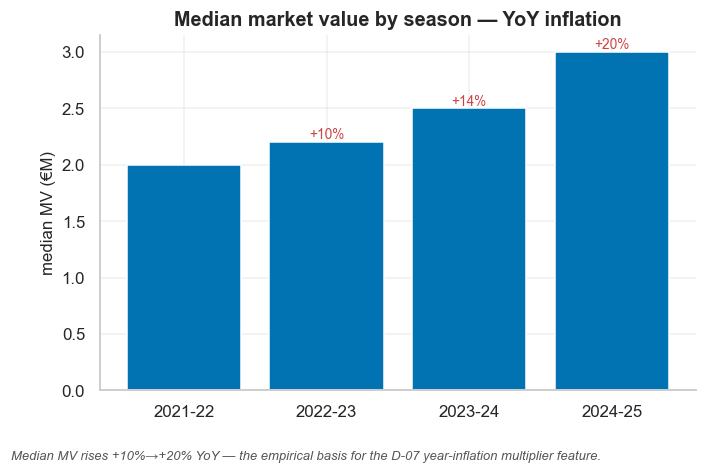

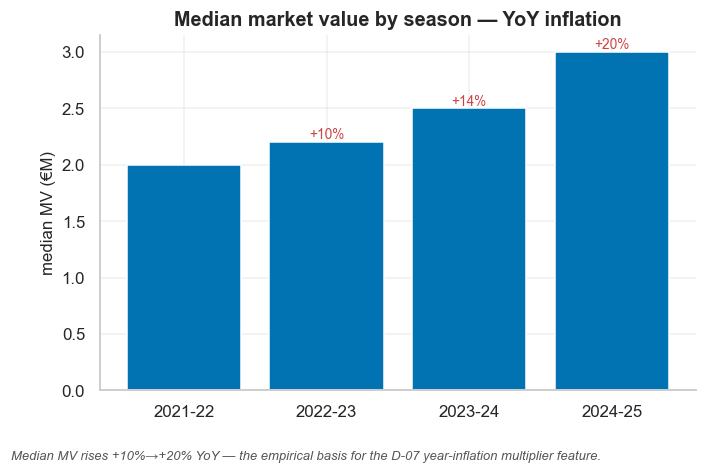

In [7]:
plots.fig03_mv_median_by_season(panel)

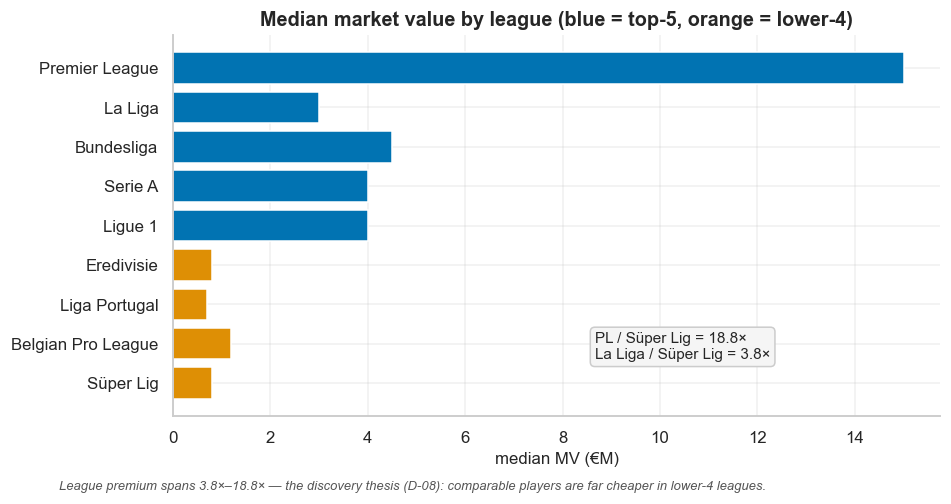

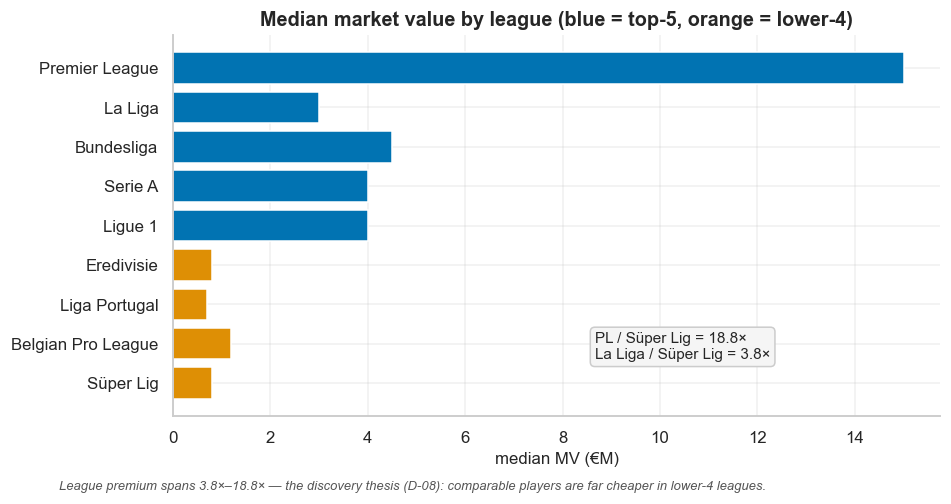

In [8]:
plots.fig04_mv_median_by_league(panel)

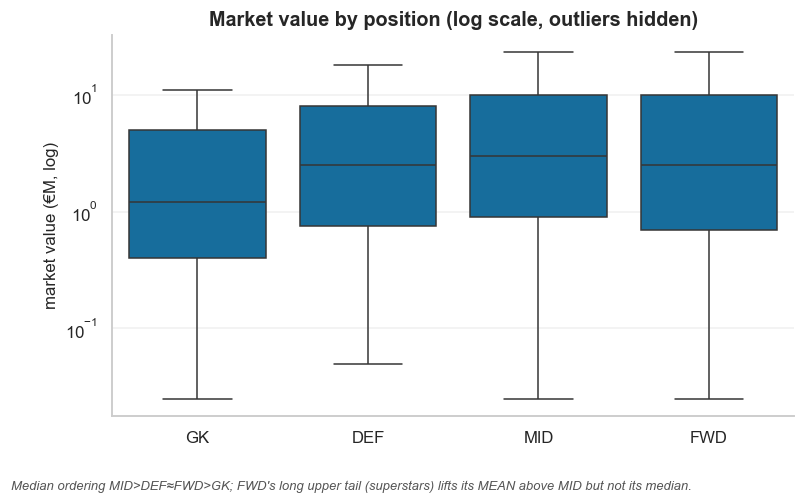

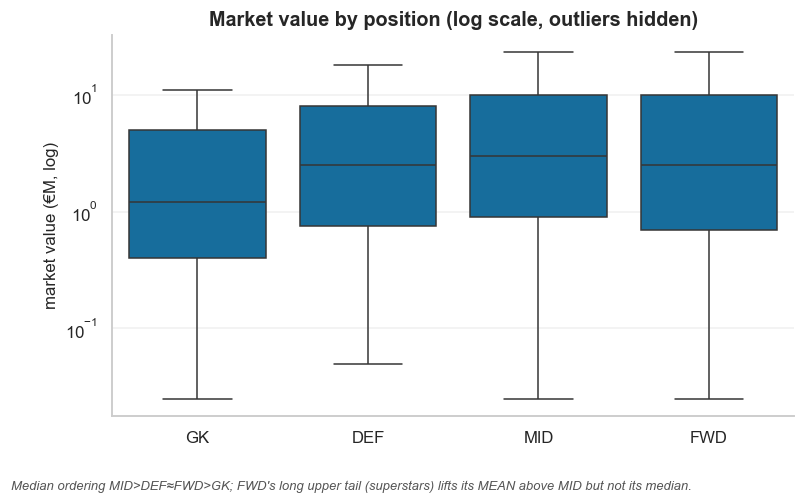

In [9]:
plots.fig05_mv_by_position_box(panel)

**Closing note.** Raw MV is extreme right-skew (skew **4.2**, kurtosis **27**); `log1p`
collapses it to ≈normal (skew **−0.03**, Shapiro W **0.99**) — empirically confirming
Stage-2's `log1p` target (D-05): a raw target would inflate squared error on the handful
of €100M+ players and bias the model toward them. Median MV rises **+10% → +20% YoY**
(the basis for the D-07 inflation multiplier). The league premium spans **3.8× (La Liga
vs Süper Lig) to 18.8× (PL vs Süper Lig)** — visual proof of the discovery thesis (D-08).
By position, the **median** orders MID > DEF ≈ FWD > GK, but FWD's long superstar tail
lifts its **mean** above MID — so position stratification (D-03) is justified and
position-conditional value drivers differ. **Phase 6:** train on `log1p(mv)`, invert with
`expm1`, report € error after inversion.

## 3 — Missing-data audit

Two very different kinds of missingness must be distinguished: **structural** (a stat is
null because it doesn't apply to a position — GK stats for outfielders) versus
**source-gap** (a source doesn't cover a league/season — xG in lower-4, FC25 potential).
Conflating them would mislead Phase-4 imputation.

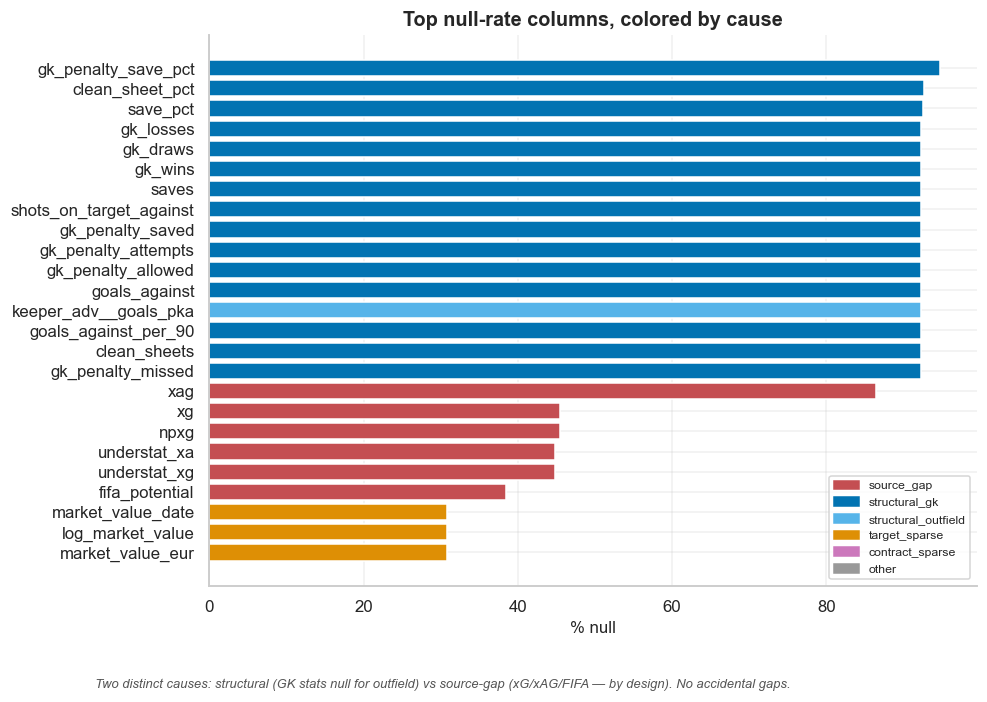

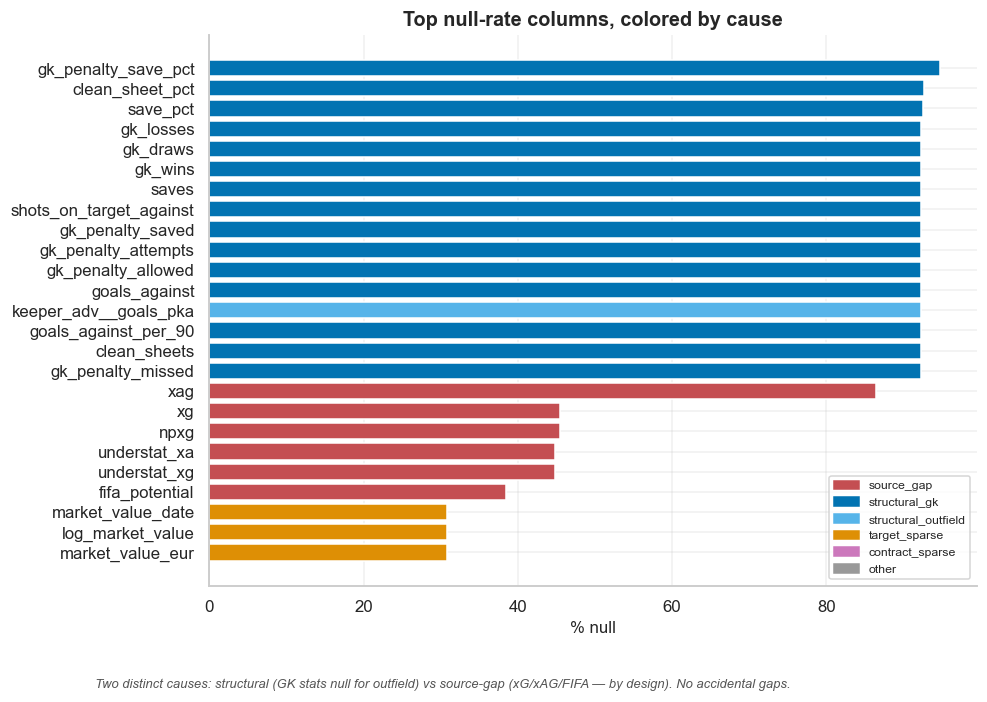

In [10]:
plots.fig06_null_rate_top(panel)

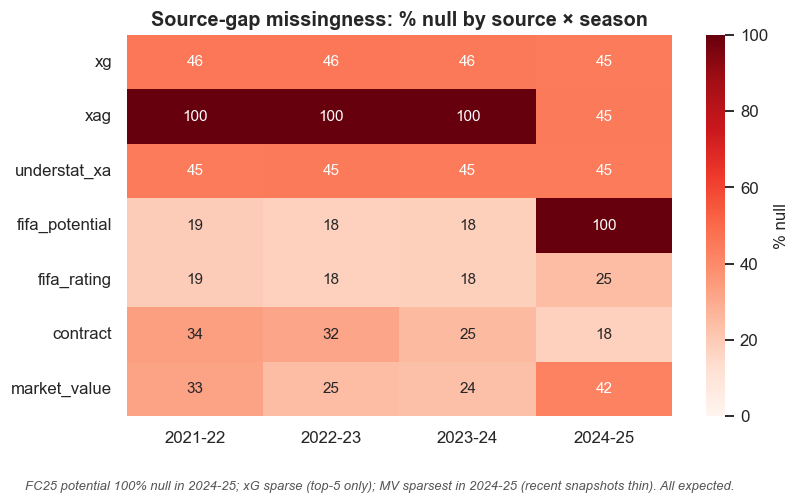

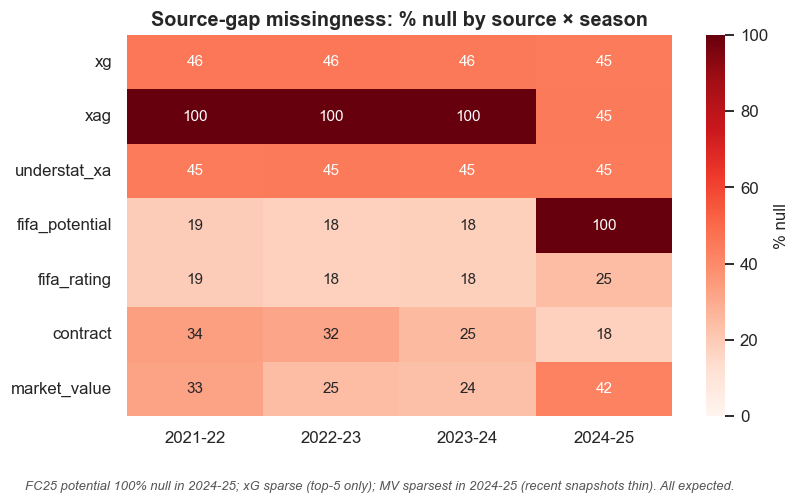

In [11]:
plots.fig07_missing_by_source_season(panel)

In [12]:
proof = S.missingness(panel)["proof"]
pd.Series({k: round(v*100, 1) for k, v in proof.items()}, name="% null").to_frame()

,% null
saves_null_overall,92.3
saves_null_within_gk,0.1
xg_null_lower4,100.0
xg_null_top5,1.8
xag_null_overall,86.4
fifa_potential_null_2425,100.0
contract_null_overall,27.3
mv_null_overall,30.8


**Closing note.** `saves` is 92% null overall but **0.1% within GK** — pure *structural*
missingness, not a gap. The *source-gap* nulls are by design: xG ~45% null (lower-4 has
none; pre-2024-25 top-5 comes from Understat), xag ~86% (Kaggle 2024-25 top-5 only), FC25
`potential` 100% null in 2024-25, MV sparsest in 2024-25 (~58%, recent snapshots thin).
The 106 soccerdata-empty extended columns were already dropped (P2-D6), so no *accidental*
gaps remain. **Phase 4:** tree models (XGBoost/LightGBM) tolerate NaN natively, but encode
position-conditional missingness explicitly (an `is_gk` mask; separate GK feature block)
and leave lower-4 xG NaN rather than imputing a fake value.

## 4 — Position distribution & taxonomy validation

The pipeline is position-stratified (D-03), so the GK/DEF/MID/FWD taxonomy must be sane:
realistic position shares, and position changes across seasons should reflect real
re-classifications (e.g. a winger logged as MID then FWD), not noise.

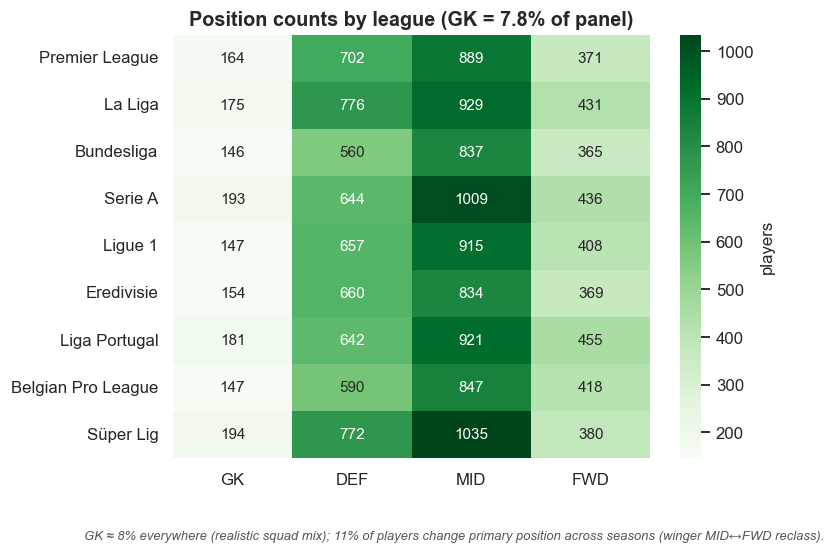

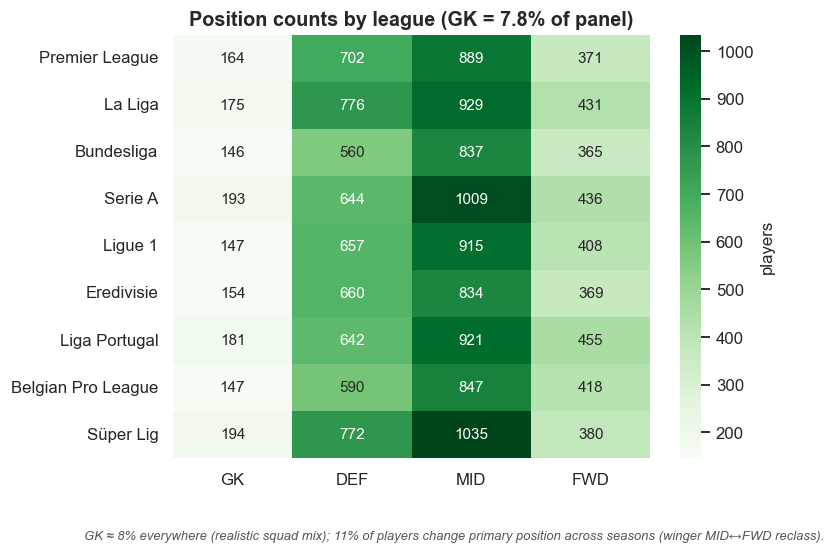

In [13]:
plots.fig08_position_by_league_heatmap(panel)

In [14]:
ps = S.position_stats(panel)
print(f"GK share: {ps['gk_pct']:.1f}%  |  players changing primary position across seasons: "
      f"{ps['n_position_changers']} ({ps['pct_position_changers']:.1f}%)")
ps['counts'].to_frame('player-seasons')

GK share: 7.8%  |  players changing primary position across seasons: 1019 (11.2%)


,player-seasons
primary_position,
GK,1501
DEF,6003
MID,8216
FWD,3633


**Closing note.** GK ≈ **8%** of rows everywhere (a realistic squad mix); MID (42%) > DEF
(31%) > FWD (19%) > GK (8%). **11.2%** of players change primary position across seasons —
inspection shows these are genuine winger MID↔FWD reclassifications (e.g. Saka, Martinelli),
not errors. **Phase 5:** stratify each model by `primary_position`, and assign a player to a
stage using their *season-specific* position (not a career-fixed one), since it legitimately
shifts.

## 5 — Age distribution & the value curve

Age is one of the strongest value drivers. We check the age distribution for sanity, then
the age × MV curve per position (LOWESS) to locate peak-value age — the backbone of the
Phase-4 age-curve feature.

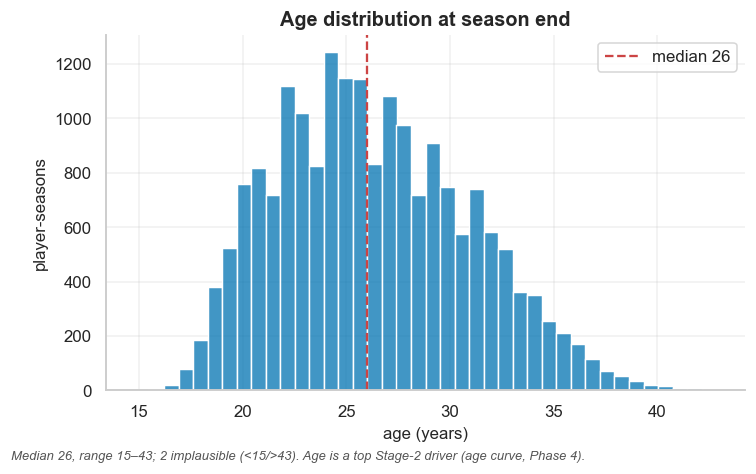

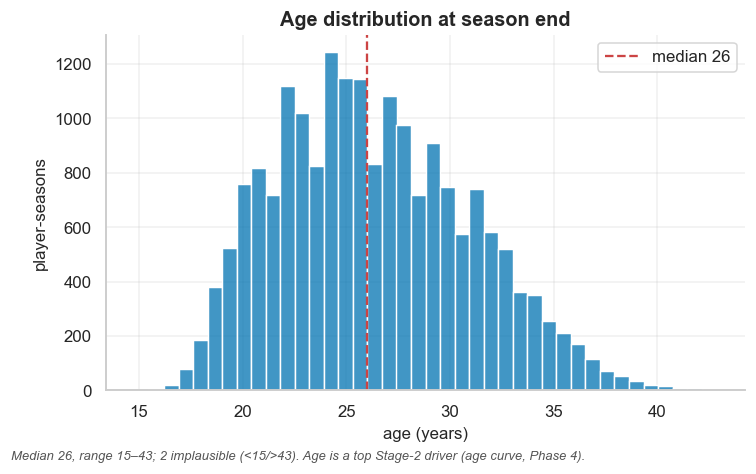

In [15]:
plots.fig09_age_hist(panel)

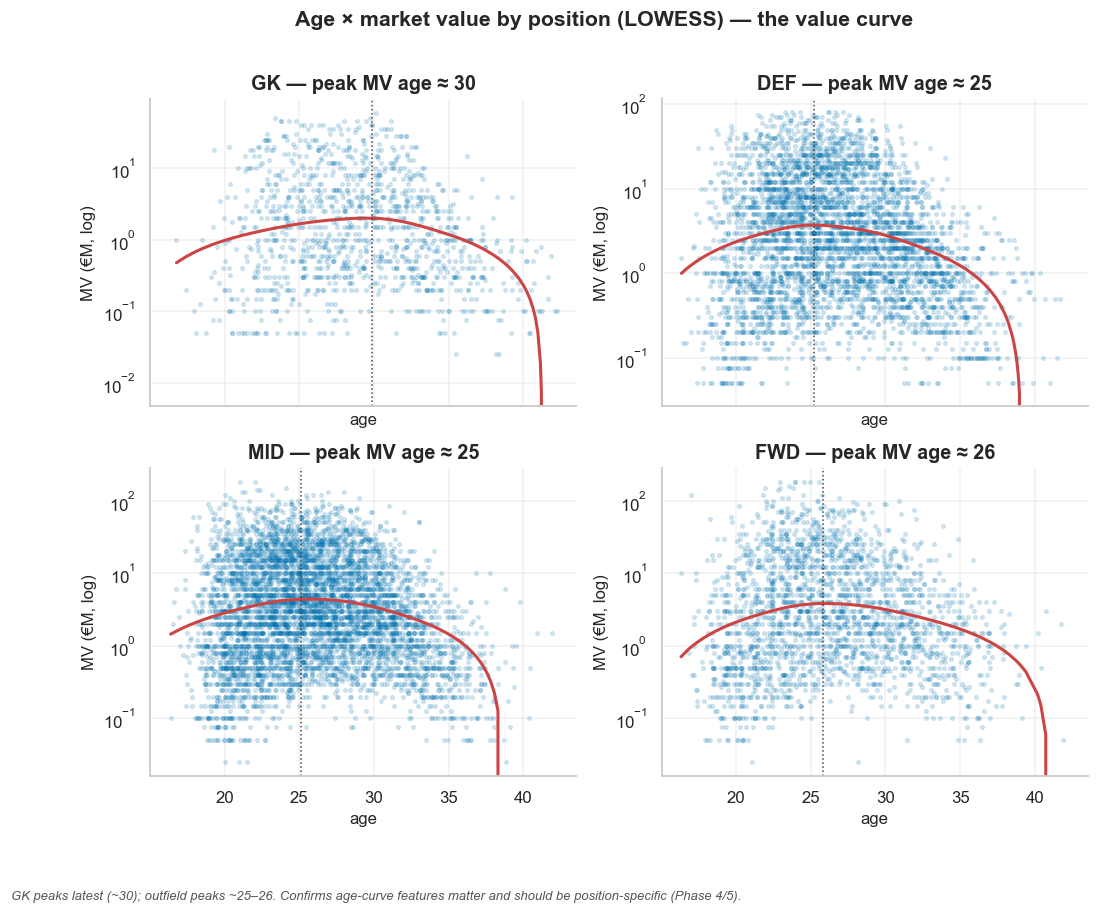

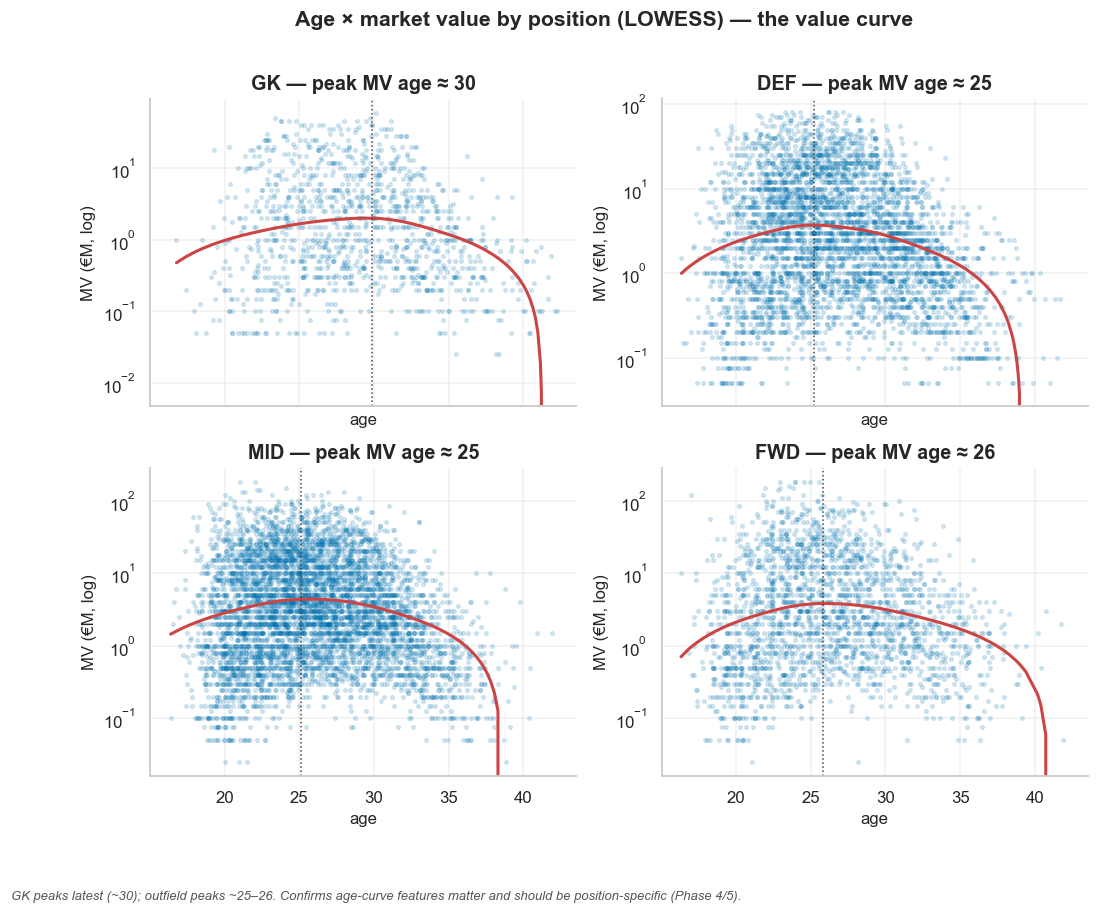

In [16]:
plots.fig10_age_vs_mv_lowess(panel)

In [17]:
a = S.age_stats(panel)
print(f"age: min {a['min']:.1f}, median {a['median']:.1f}, max {a['max']:.1f}, "
      f"implausible {a['n_implausible']}")
pd.Series({k: (round(v,1) if v else None) for k,v in a['peak_age_by_position'].items()},
          name="peak MV age").to_frame()

age: min 14.8, median 26.0, max 42.8, implausible 2


,peak MV age
GK,29.9
DEF,25.2
MID,25.1
FWD,25.8


**Closing note.** Age is well-formed (median **26**, range 14.8–42.8, only 2 implausible
youth rows). The LOWESS value curve peaks **~25–26 for outfielders but ~30 for GKs** —
goalkeepers hold value far later. **Phase 4:** build position-specific age-curve features
(distance-from-peak, age², is_peak_window); a single global age term would mis-price GKs.
This is also a Stage-1 signal: young pre-peak players are exactly the projection upside.

## 6 — Trajectory case studies

Stage 1 projects *next-season* stats from a player's history, so multi-season trajectories
matter. Four archetypes: a young riser (Bellingham), a peak/cross-league mover (Kane), a
late-career outlier (Modrić), and a lower→top-5 mover (Minteh).

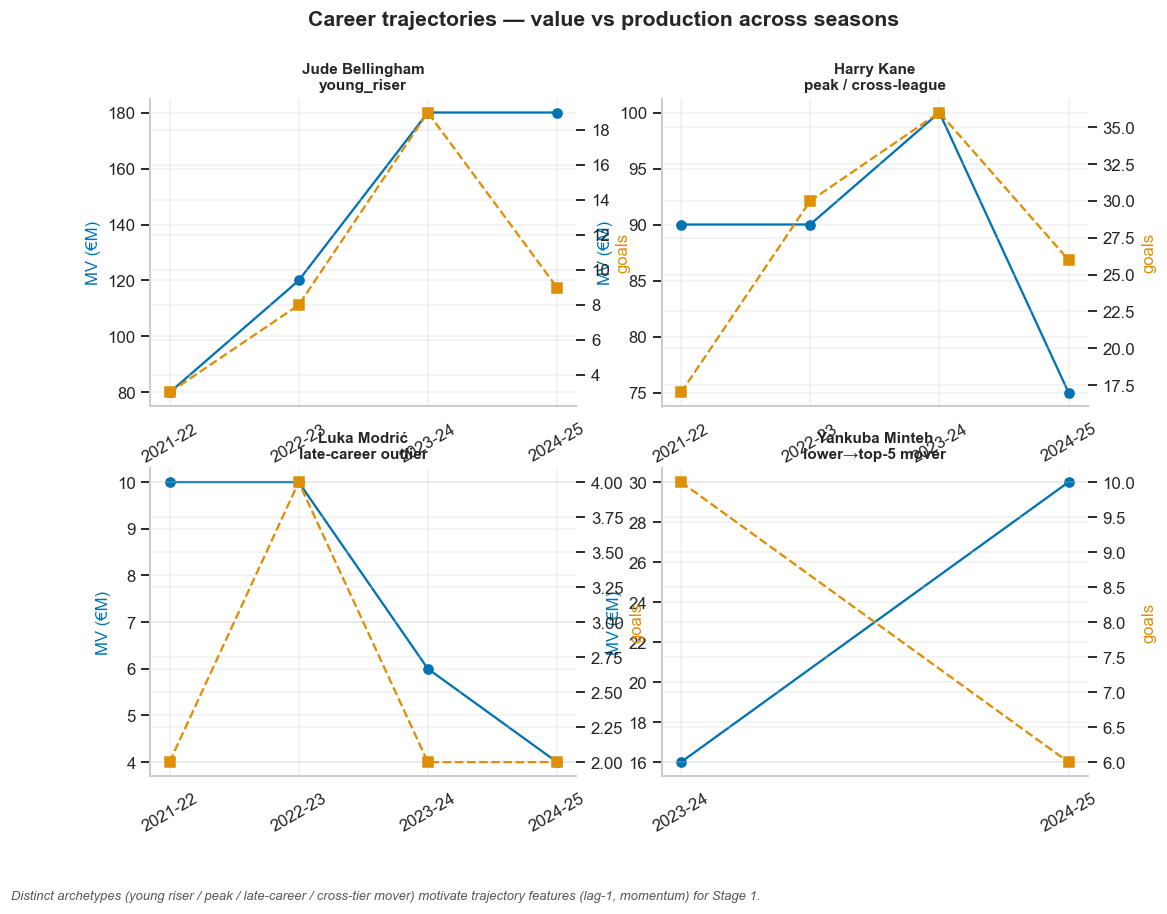

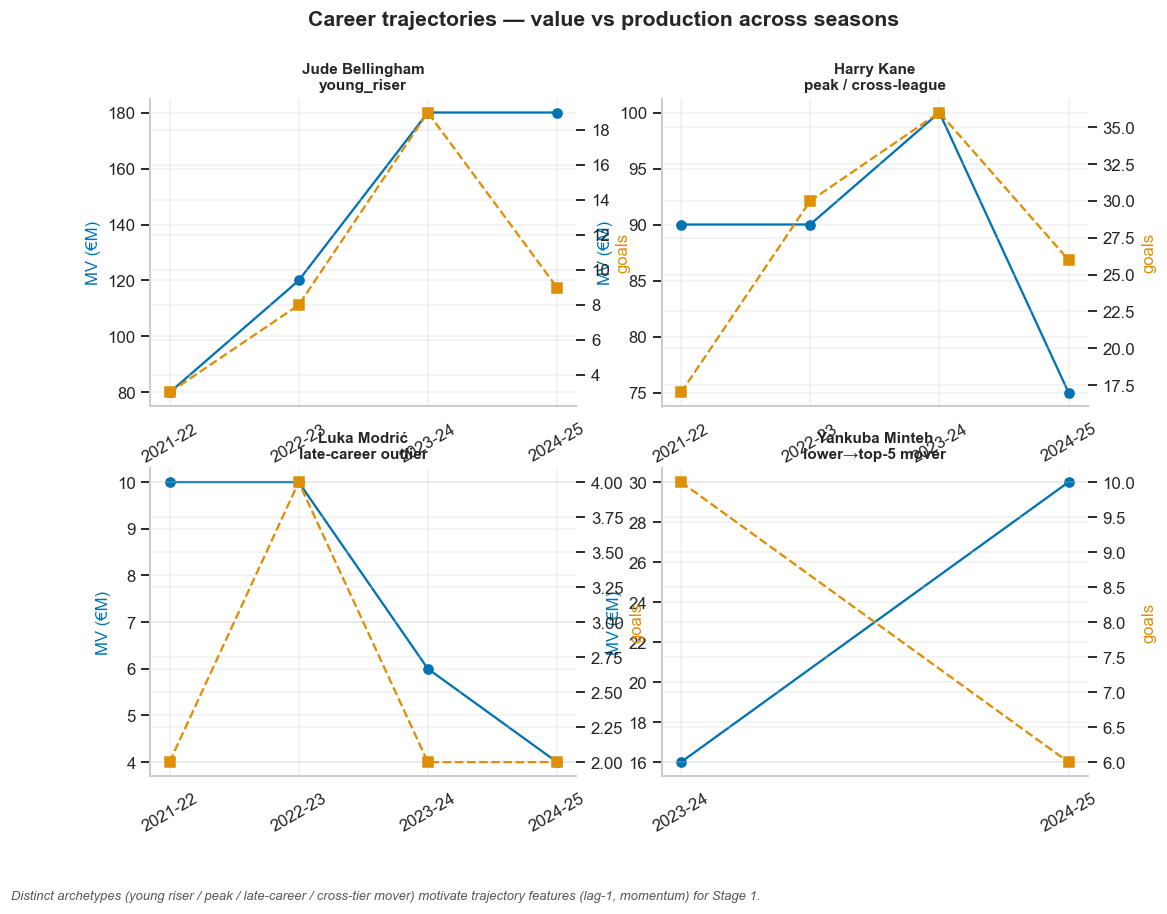

In [18]:
plots.fig11_case_study_trajectories(panel)

**Closing note.** The four trajectories show distinct shapes — Bellingham's steep MV+goals
rise, Kane's high plateau through a cross-league move, Modrić's late-career value retention,
and Minteh's Eredivisie→PL jump. This is the visual case for **trajectory features** (lag-1
stats, season-over-season deltas, momentum) as Stage-1 inputs (§10.9). **Phase 4:** prioritise
lag-1 (most recent season) and a 2-season slope; require ≥2 consecutive seasons for a
training pair (§6.3).

## 7 — League comparison & the discovery signal

The project's thesis: lower-tier leagues are under-priced relative to performance. We
compare scoring productivity across leagues to argue that lower-4 forwards are *not* less
productive — just cheaper.

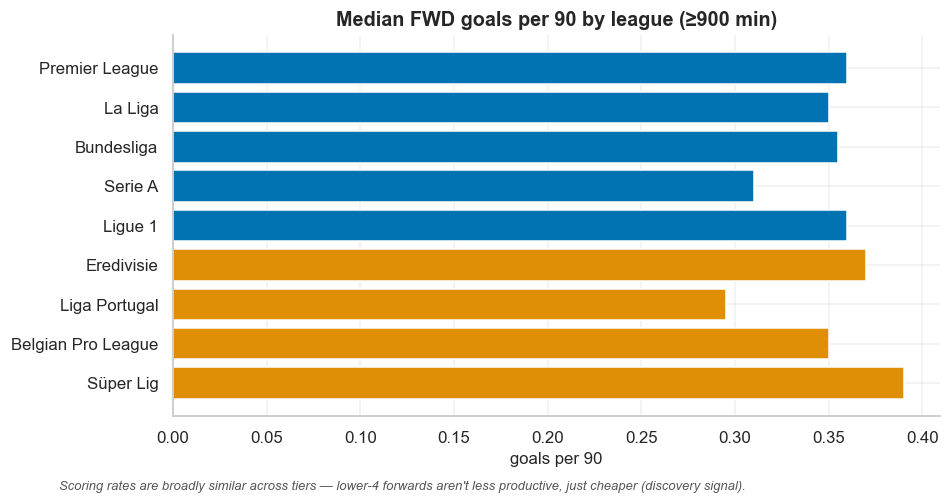

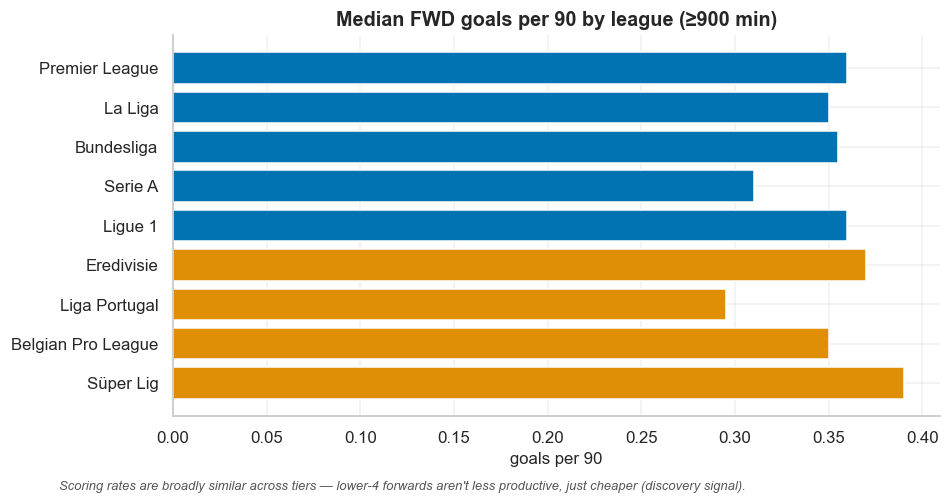

In [19]:
plots.fig12_fwd_goals_per90_by_league(panel)

**Closing note.** Median FWD goals-per-90 (≥900 min) is broadly comparable across tiers —
lower-4 forwards score at similar rates to mid-table top-5 forwards, yet their median MV is
**3.8–18.8× lower** (Section 2). That gap between *comparable production* and *much lower
price* is the discovery signal the pipeline is built to exploit (D-08). **Phase 8:** train
Stage 2 on top-5 (efficient pricing) and apply to lower-4, ranking by `value_gap ×
confidence`; calibrate cross-league via the transferred-player cohort.

## 8 — xG vs goals calibration

xG comes from two sources (Kaggle 2024-25, Understat historical) with different models.
We validate calibration and quantify the source difference noted in Phase 1B.

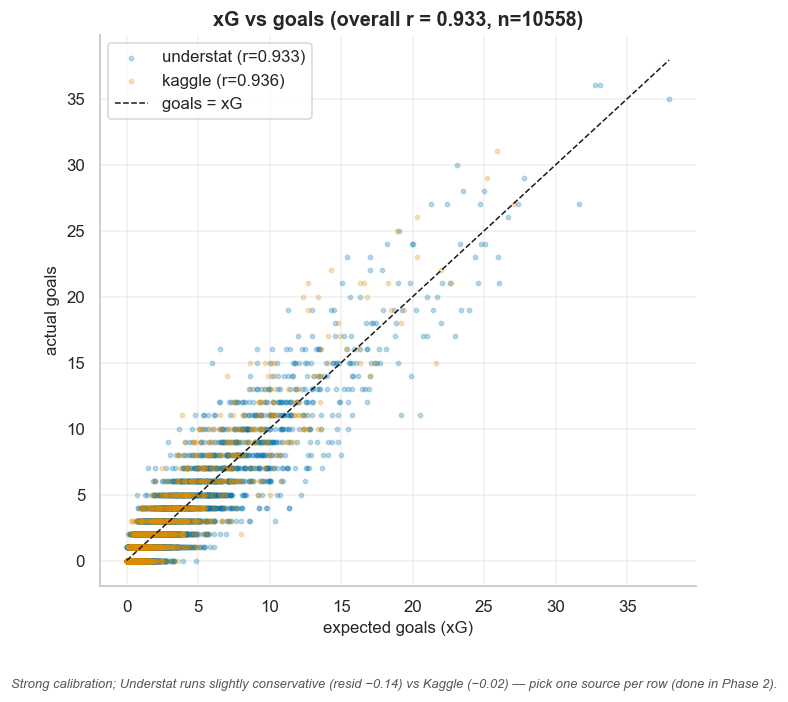

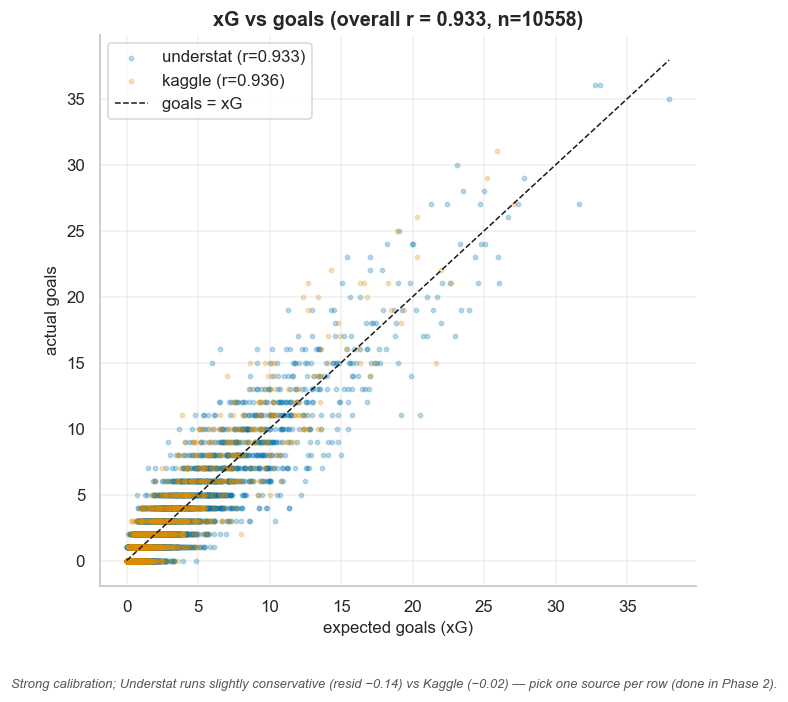

In [20]:
plots.fig13_xg_vs_goals_scatter(panel)

In [21]:
x = S.xg_calibration(panel)
print(f"overall pearson r = {x['pearson_overall']:.3f} (n={x['n']:,})")
for src, d in x['by_source'].items():
    print(f"  {src:10s}: r={d['pearson']:.3f}  mean(goals-xg)={d['mean_resid_goals_minus_xg']:+.3f}  (n={d['n']:,})")

overall pearson r = 0.933 (n=10,558)
  kaggle    : r=0.936  mean(goals-xg)=-0.019  (n=2,628)
  understat : r=0.933  mean(goals-xg)=-0.140  (n=7,930)


**Closing note.** xG tracks goals tightly (**r = 0.93**). The two sources differ as the
memory note flagged: Understat runs slightly conservative (mean residual **−0.14**) vs
Kaggle (**−0.02**) — confirming they're not directly comparable on absolute scale, only on
rank. Phase 2 already picks **one source per row** (Kaggle for 2024-25 top-5, Understat
historical). **Phase 4:** don't mix `xg` and `understat_xa` in one column; if an xAG
trajectory is needed, derive a position-based `understat_xa → xag` factor (deferred, P2-D3).

## 9 — Provenance audit (Phase-2 quality)

The panel carries resolution metadata (`resolve_method`, `data_richness`, `age_precision`).
This section audits Phase-2's name-resolution quality and locates the synthetic cohort.

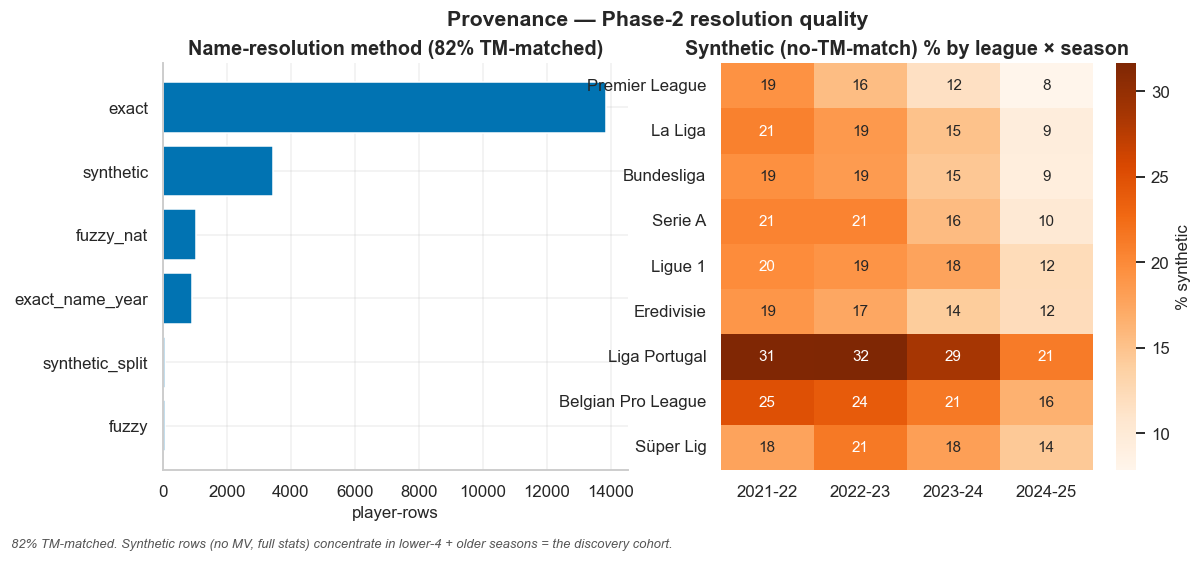

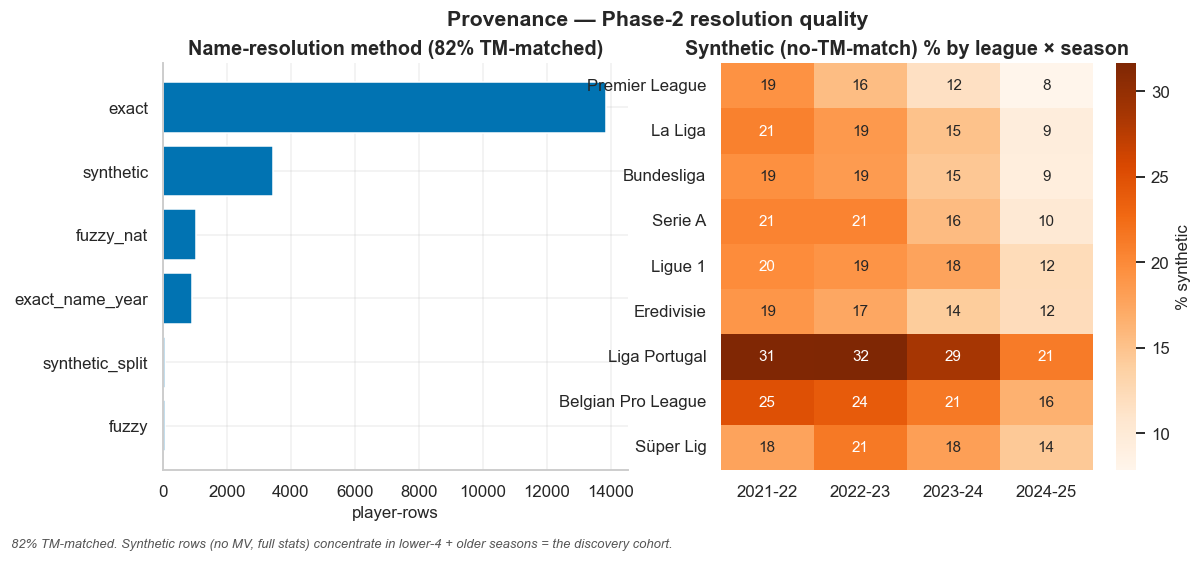

In [22]:
plots.fig14_provenance(panel)

In [23]:
pr = S.provenance_stats(panel)
print(f"TM-matched: {pr['tm_matched_pct']:.1f}%")
display(pr['resolve_method'].to_frame('rows'))
display(pr['age_precision'].to_frame('rows'))

TM-matched: 81.6%


,rows
resolve_method,
exact,13835
synthetic,3440
fuzzy_nat,1048
exact_name_year,916
synthetic_split,62
fuzzy,55


,rows
age_precision,
exact,15854
year_only,3502


**Closing note.** **82% of rows are TM-matched** (71% exact); the remaining 18% are
`synthetic` — players with no Transfermarkt match, so **no market value but full FBref
stats**. They concentrate in lower-4 leagues and older seasons (players who since left the
9-league set). These are *not* errors: they're the lower-league discovery cohort, and
Stage 2 naturally excludes them via `market_value.notna()`. **Phase 5/8:** filter Stage-2
training to `resolve_method ∈ matched`; keep synthetics for Stage-1 projection + discovery.

## 10 — Outlier investigation

A final data-quality pass: are the extreme values real? We check the top market values and
the suspicious low-minute / high-value corner.

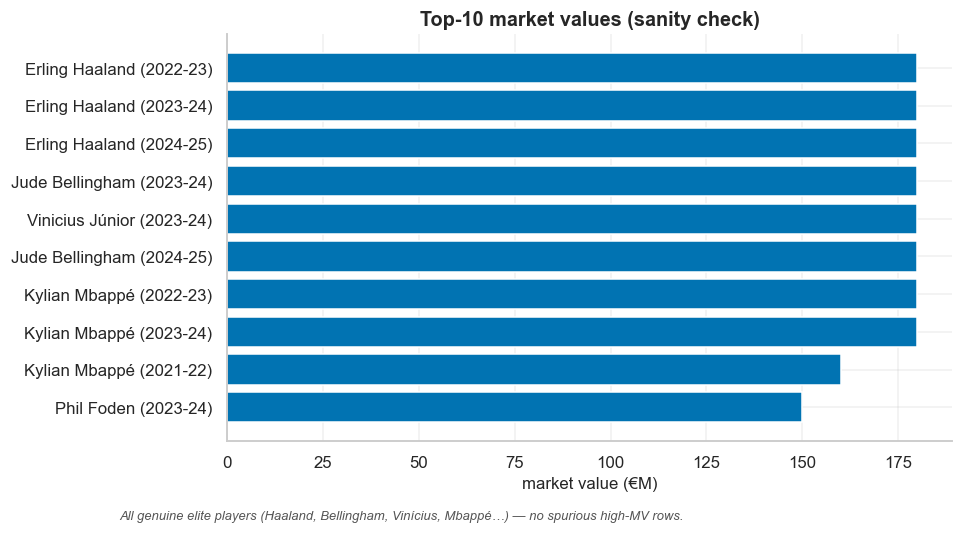

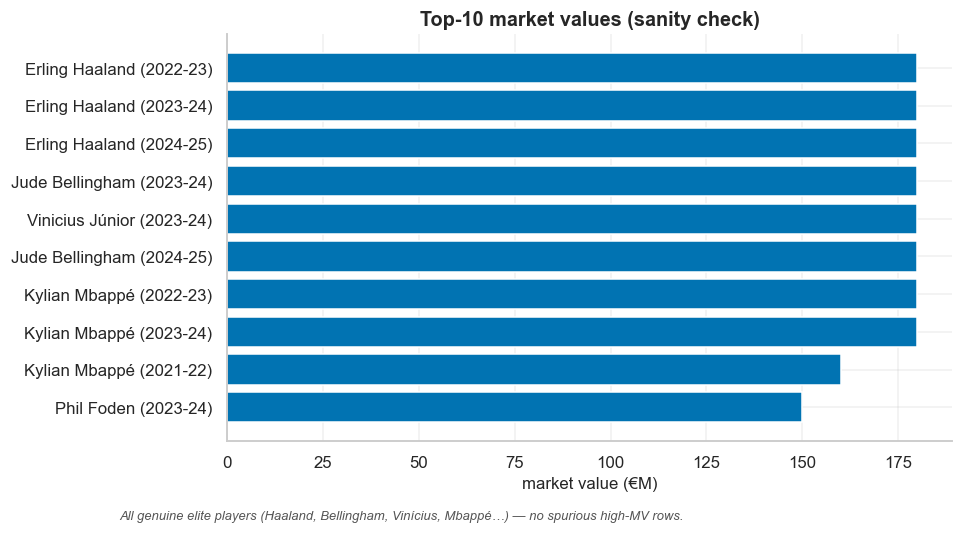

In [24]:
plots.fig15_top10_mv(panel)

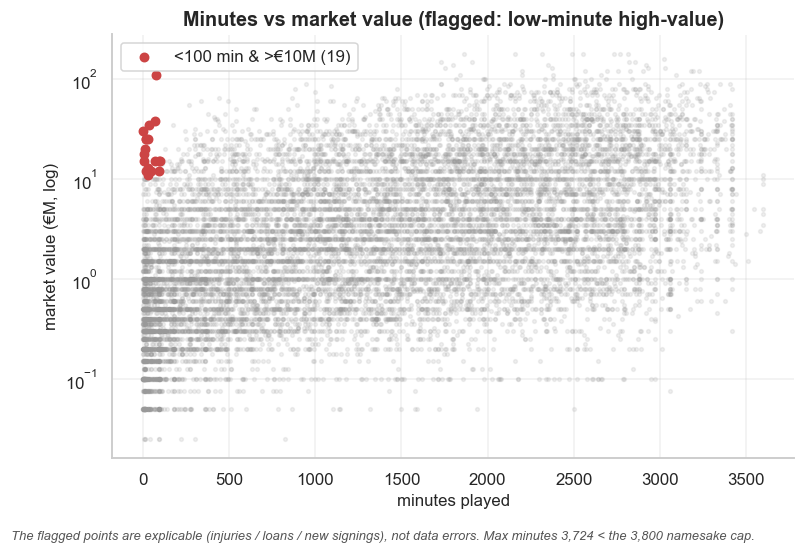

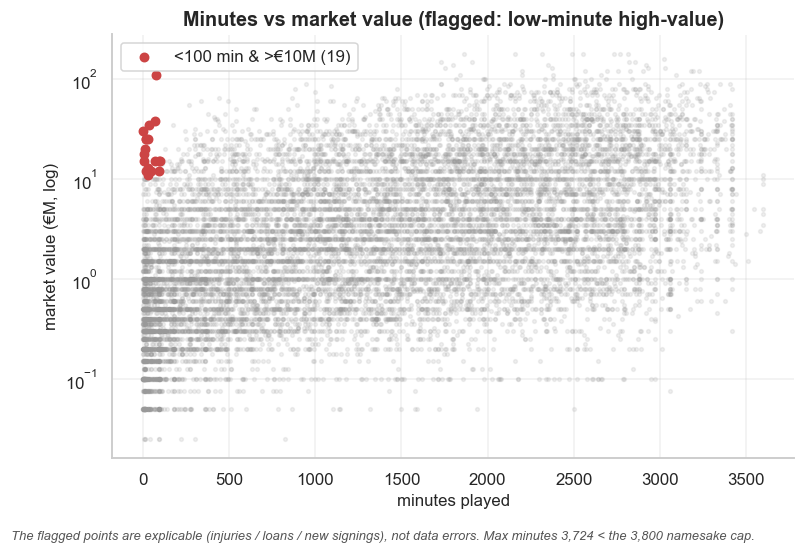

In [25]:
plots.fig16_minutes_vs_mv(panel)

In [26]:
o = S.outliers(panel)
print(f"low-minute (<100) high-MV (>€10M) rows: {o['n_low_min_high_mv']}  |  "
      f"max minutes: {o['max_minutes']:.0f}  |  rows >3500 min: {o['n_over_3500_min']}")
pd.DataFrame(o['low_min_examples'])

low-minute (<100) high-MV (>€10M) rows: 19  |  max minutes: 3724  |  rows >3500 min: 11


,player_name,season,minutes_played,market_value_eur
0,Rodri,2024-25,73,110000000.0
1,Jurriën Timber,2023-24,71,38000000.0
2,Roméo Lavia,2023-24,33,35000000.0
3,Vitor Reis,2024-25,1,30000000.0
4,Valentino Livramento,2022-23,28,25000000.0


**Closing note.** No spurious values: the top-10 MVs are all genuine elite players
(Haaland, Bellingham, Vinícius, Mbappé…), and the 19 low-minute/high-MV rows are all
explicable (injuries, loans, new signings — e.g. Timber's injury return). Max minutes is
**3,724 < the 3,800 namesake cap** (Phase-2 guard working). **Phase 4:** no outlier removal
needed on the target; cap or winsorize only if a specific feature shows instability.

## Summary — key empirical findings

1. **Log MV transform empirically justified** (skew 4.2 → −0.03, Shapiro W 0.99).
2. **League premium 3.8×–18.8×** (comparable mid-table vs PL extreme) — the discovery signal.
3. **MV median MID > DEF ≈ FWD > GK** (FWD's superstar tail lifts the mean, not the median).
4. **YoY MV inflation +10–20%** — grounds the D-07 inflation multiplier.
5. **Synthetic cohort (18%)** = lower-league discovery target: stats-rich, MV-absent.

Plus the structural finding that drove the Phase-2 §6.2 revision: **soccerdata's FBref
extended stats are unavailable** (tackles/passing/possession/creation/PSxG), so Stage-1
targets are reduced to the surviving stat universe + xG/xAG.

Full write-up in `reports/eda_findings.md`.